# Week 1: Data Collection & Preprocessing
This notebook is for the Week 1 module of the **Eco-Aware Personal Assistant** project.
It includes:
- Creating a sample AQI dataset
- Preprocessing data
- Handling missing values
- Feature engineering
- Data visualization
- Saving the processed data for Week 2

In [1]:
!pip install pandas numpy matplotlib seaborn requests


   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
    --------------------------------------- 0.3/11.0 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.0 MB 807.1 kB/s eta 0:00:13
   - -------------------------------------- 0.5/11.0 MB 807.1 kB/s eta 0:00:13
   -- ------------------------------------- 0.8/11.0 MB 733.3 kB/s eta 0:00:14
   -- ------------------------------------- 0.8/11.0 MB 733.3 kB/s eta 0:00:14
   -- ------------------------------------- 0.8/11.0 MB 733.3 kB/s eta 0:00:14
   --- ------------------------------------ 1.0/11.0 MB 571.2 kB/s eta 0:00:18
   --- ------------------------------------ 1.0/11.0 MB 571.2 kB/s eta 0:00:18
   --- ------------------------------------ 1.0/11.0 MB 571.2 kB/s eta 0:00:18
   ---- ----------


[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Import all necessary libraries
import pandas as pd       # For working with tabular data
import numpy as np        # For numerical operations
import matplotlib.pyplot as plt  # For plotting basic charts
import seaborn as sns     # For advanced plotting
from datetime import datetime, timedelta  # For handling date and time

print("All libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


All libraries imported successfully!


In [4]:
# Generate hourly timestamps for 30 days
dates = pd.date_range(start="2025-08-01", periods=30*24, freq='H')

# Ensure reproducibility
np.random.seed(42)

# Generate random AQI, Temperature, Humidity, Traffic_Level
aqi_values = np.random.randint(50, 250, size=len(dates))
temperature_values = np.random.randint(20, 40, size=len(dates))
humidity_values = np.random.randint(30, 90, size=len(dates))
traffic_values = np.random.randint(1, 10, size=len(dates))

# Create DataFrame
df = pd.DataFrame({
    'Date': dates,
    'AQI': aqi_values,
    'Temperature': temperature_values,
    'Humidity': humidity_values,
    'Traffic_Level': traffic_values
})

# Display first 5 rows
df.head()

C:\Users\monik\AppData\Local\Temp\ipykernel_4812\1340852658.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(start="2025-08-01", periods=30*24, freq='H')


,Date,AQI,Temperature,Humidity,Traffic_Level
0,2025-08-01 00:00:00,152,25,63,2
1,2025-08-01 01:00:00,229,31,59,7
2,2025-08-01 02:00:00,142,32,88,6
3,2025-08-01 03:00:00,64,32,84,4
4,2025-08-01 04:00:00,156,34,42,7


In [5]:
# Introduce 5% missing values in AQI and Temperature
for col in ['AQI', 'Temperature']:
    df.loc[df.sample(frac=0.05).index, col] = np.nan

# Check the number of missing values in each column
df.isnull().sum()
# Fill missing values with the mean of the respective columns

Date              0
AQI              36
Temperature      36
Humidity          0
Traffic_Level     0
dtype: int64

In [6]:
# Summary statistics for numeric columns
df.describe()

,Date,AQI,Temperature,Humidity,Traffic_Level
count,720,684.000000,684.000000,720.000000,720.00000
mean,2025-08-15 23:30:00,153.770468,29.251462,60.070833,5.00000
min,2025-08-01 00:00:00,50.000000,20.000000,30.000000,1.00000
25%,2025-08-08 11:45:00,103.000000,24.000000,44.000000,3.00000
50%,2025-08-15 23:30:00,157.000000,29.000000,61.000000,5.00000
75%,2025-08-23 11:15:00,201.000000,34.000000,75.000000,7.00000
max,2025-08-30 23:00:00,249.000000,39.000000,89.000000,9.00000
std,NaN,56.700143,5.854101,17.490366,2.53652


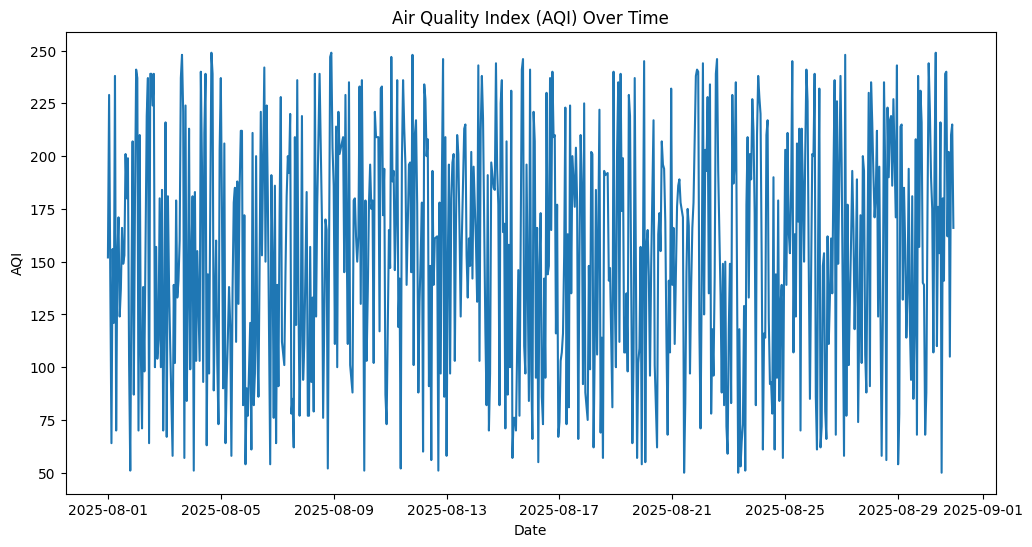

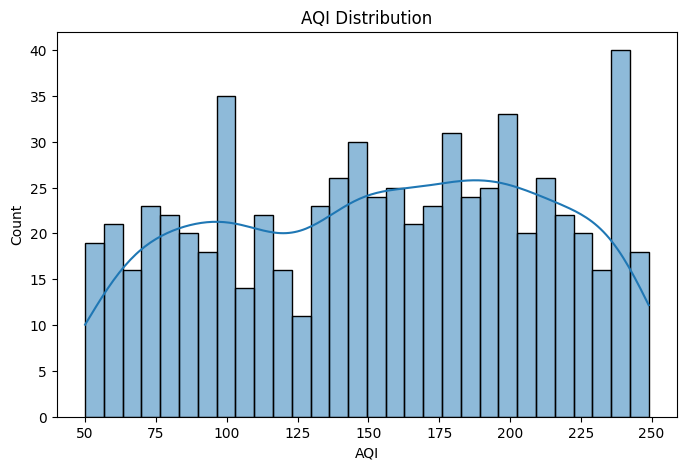

In [7]:
# AQI trend over time
plt.figure(figsize=(12,6))
sns.lineplot(x='Date', y='AQI', data=df)
plt.title('Air Quality Index (AQI) Over Time')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.show()

# AQI distribution
plt.figure(figsize=(8,5))
sns.histplot(df['AQI'], bins=30, kde=True)
plt.title('AQI Distribution')
plt.xlabel('AQI')
plt.show()


In [8]:
# Save the cleaned dataset for Week 2
df.to_csv("processed_air_quality.csv", index=False)
print("Processed data saved as 'processed_air_quality.csv'")


Processed data saved as 'processed_air_quality.csv'
